In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objs as go
import random

from winetasting import WineTasting

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [164]:
wine_tasting = WineTasting()
wine_tasting.load_example_data()

In [165]:
wine_tasting.get_results()

# Announcements:
- There are 12 number of wines
- The order of tasting is randomized
- We will taste in batches of 2-3 then reveal
- Please let me open each wine bottle
- There are some wine types with multiple, so just because you saw it already does not mean it won't show up again
- And technically some are not strictly speaking _wine_
- You will guess the wine type and the price
- There is a written list of the types of wine here today, plus a few red herrings
- Price per bottle is always lower than \\$50
- Whomever gets the most wine types correct wins \\$40, 2nd place is \\$20
- Whomever gets the closest average price wins \\$40, 2nd place is \\$20
- Spread the love, no repeat winners
- Ties might result in a taste-off

In [74]:
answer_df = pd.DataFrame([
    [28, 'argentina',      'wapisa',             'malbec', 15],
    [54, 'italy',          'kirkland',           'pinot_grigio', 5],
    [86, 'spain',          'carrasvinas',        'verdejo', 8],
    [30, 'italy',          'kirkland',           'prosecco', 8],
    [92, 'usa_california', 'burgess',            'cabernet_sauvignon', 43],
    [49, 'france',         'cheateau_picadis',   'bordeaux', 7],
    [13, 'usa_oregon',     'a_to_z_wineworks',   'riesling', 13],
    [18, 'usa_california', 'taken_wine_company', 'red_blend', 16],
    [11, 'bulgaria',       'rough_day',          'cabernet_sauvignon', 9],
    [88, 'spain',          'esteban_martin',     'syrah', 5],
    [65, 'italy',          'bottega_vinaia',     'pinot_grigio', 12],
    [96, 'france',         'moet_&_chandon',     'champagne', 45],
], columns = ['wine_id', 'country', 'brand', 'wine_type', 'price'])
answer_df = answer_df.convert_dtypes()
answer_df.head()

,wine_id,country,brand,wine_type,price
0,28,argentina,wapisa,malbec,15
1,54,italy,kirkland,pinot_grigio,5
2,86,spain,carrasvinas,verdejo,8
3,30,italy,kirkland,prosecco,8
4,92,usa_california,burgess,cabernet_sauvignon,43


In [75]:
answer_df['price'].sum()

186

In [76]:
red_herring_wines = ['zinfandel', 'moscato', 'grenache', 'pinot_noir', 'sauvignon_blanc']
all_wine_types = answer_df['wine_type'].unique().tolist()
all_wine_types = list(set(all_wine_types + red_herring_wines))
all_wine_types.sort()
all_wine_types

['bordeaux',
 'cabernet_sauvignon',
 'champagne',
 'grenache',
 'malbec',
 'moscato',
 'pinot_grigio',
 'pinot_noir',
 'prosecco',
 'red_blend',
 'riesling',
 'sauvignon_blanc',
 'syrah',
 'verdejo',
 'zinfandel']

In [163]:
data_df = pd.read_csv('wine_tasting/winetasting/example_guesses.csv').convert_dtypes()
data_df['guess_type'] = data_df['guess_type'].fillna('na_guess_type')
data_df['guess_price'] = data_df['guess_price'].fillna(0)
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   name         132 non-null    string
 1   wine_id      132 non-null    Int64 
 2   guess_type   132 non-null    string
 3   guess_price  132 non-null    Int64 
dtypes: Int64(2), string(2)
memory usage: 4.5 KB


In [166]:
analysis_df, results_df = wine_tasting.analysis_df.copy(), wine_tasting.results_df.copy()

In [137]:
analysis_df = data_df.merge(answer_df)
analysis_df['correct_type'] = analysis_df['wine_type'] == analysis_df['guess_type']
analysis_df['price_diff'] = analysis_df['guess_price'] - analysis_df['price']
analysis_df['abs_price_diff'] = analysis_df['price_diff'].abs()

type_accuracy_df = analysis_df.groupby(['wine_type'])['correct_type'].sum().reset_index()
type_accuracy_df = type_accuracy_df.merge(analysis_df['wine_type'].value_counts().reset_index().rename(columns={'index': 'wine_type', 'wine_type': 'total_guesses'}))
type_accuracy_df['type_accuracy'] = (100 * type_accuracy_df['correct_type'] / type_accuracy_df['total_guesses']).astype(pd.Int64Dtype())

bottle_accuracy_df = analysis_df.groupby(['wine_id'])['correct_type'].sum().reset_index()
bottle_accuracy_df = bottle_accuracy_df.merge(analysis_df['wine_id'].value_counts().reset_index().rename(columns={'index': 'wine_id', 'wine_id': 'total_guesses'}))
bottle_accuracy_df['bottle_accuracy'] = (100 * bottle_accuracy_df['correct_type'] / bottle_accuracy_df['total_guesses']).astype(pd.Int64Dtype())

analysis_df = analysis_df.merge(type_accuracy_df[['wine_type', 'type_accuracy']]).merge(bottle_accuracy_df[['wine_id', 'bottle_accuracy']])

analysis_df['percent_price_diff'] = (100 * analysis_df['price_diff'] / analysis_df['price']).round()

analysis_df.head(2)

,name,wine_id,guess_type,guess_price,country,brand,wine_type,price,correct_type,price_diff,abs_price_diff,type_accuracy,bottle_accuracy,percent_price_diff
0,Chelsey Smith,28,cabernet_sauvignon,15,argentina,wapisa,malbec,15,False,0,0,9,9,0.0
1,Jose Shields,28,cabernet_sauvignon,49,argentina,wapisa,malbec,15,False,34,34,9,9,227.0


In [79]:
results_df = analysis_df.groupby(['name'])['abs_price_diff'].sum().rename('total_price_diff').reset_index()
results_df = results_df.merge(analysis_df.groupby(['name'])['correct_type'].sum().rename('total_correct_type').reset_index())
results_df

,name,total_price_diff,total_correct_type
0,Alex Walker,141,5
1,Chelsey Smith,125,6
2,Craig Allen,110,5
3,Gina Willis,110,3
4,Jeffrey Doyle,126,2
5,Joe Armstrong,121,5
6,Jose Shields,148,4
7,Kyle Jones,117,3
8,Mark Gillespie,98,5
9,Tina Taylor,135,5


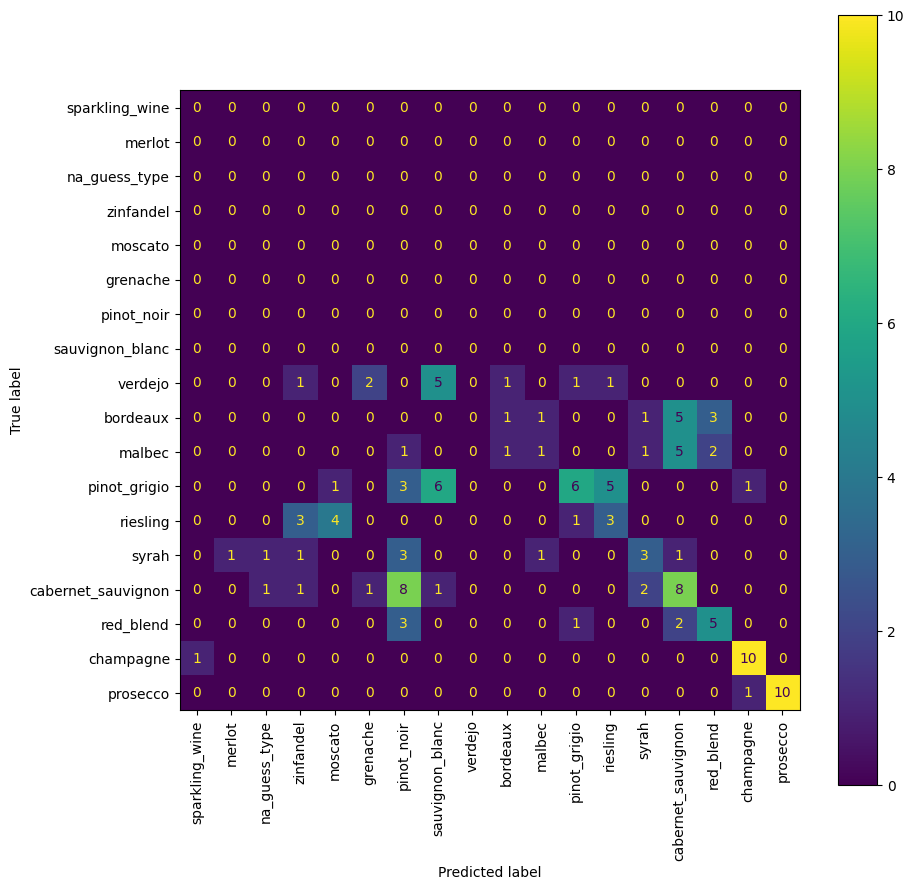

In [167]:
from winetasting import create_confusion_matrix
fig, ax = create_confusion_matrix(analysis_df, red_herring_wines)
fig

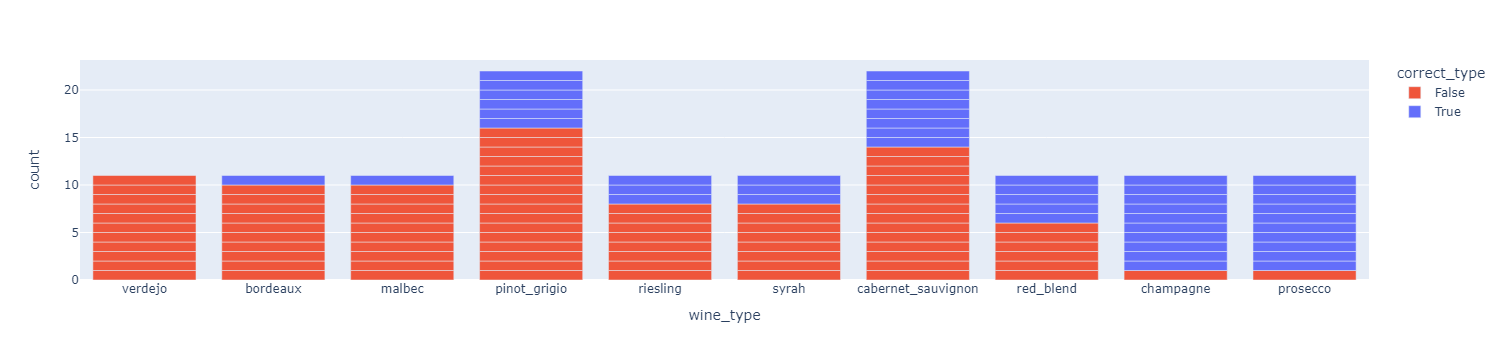

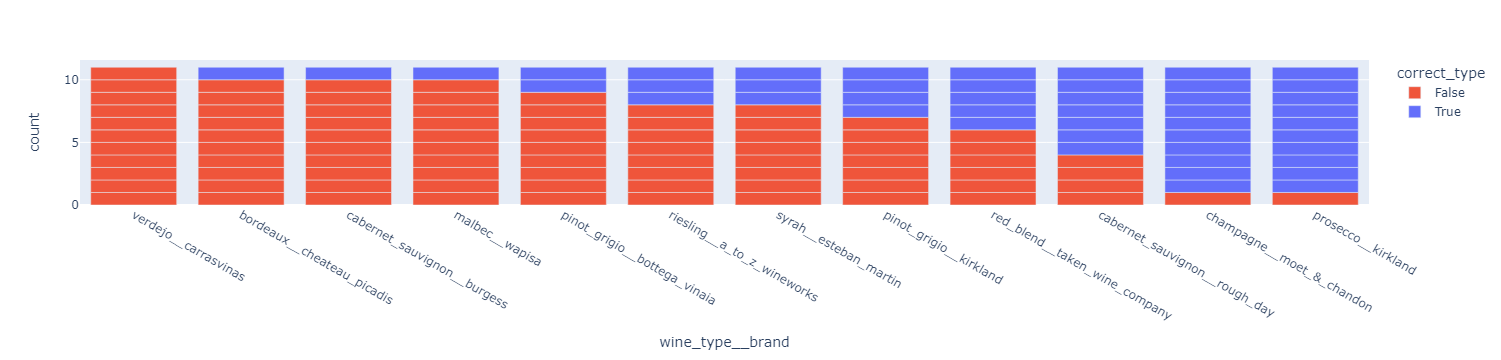

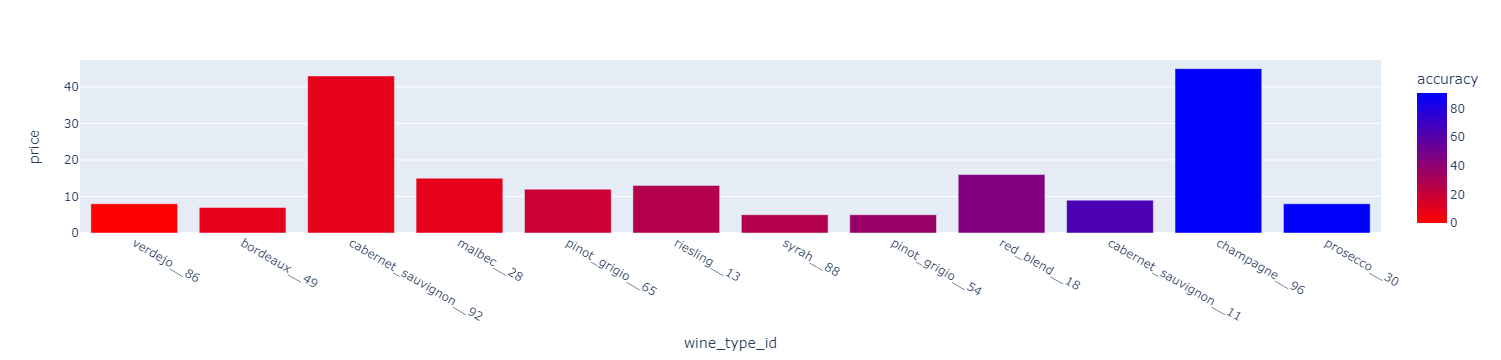

In [168]:
plot_df = analysis_df.sort_values(['type_accuracy', 'wine_type'])
px.bar(plot_df, x='wine_type', color='correct_type', color_discrete_map={True: px.colors.qualitative.Plotly[0], False: px.colors.qualitative.Plotly[1]}).show()

plot_df = analysis_df.sort_values(['bottle_accuracy', 'wine_type'])
plot_df['wine_type__brand'] = plot_df['wine_type'] + '__' + plot_df['brand']
px.bar(plot_df, x='wine_type__brand', color='correct_type', color_discrete_map={True: px.colors.qualitative.Plotly[0], False: px.colors.qualitative.Plotly[1]}).show()

plot_df = analysis_df.copy()
plot_df['wine_type_id'] = plot_df['wine_type'] + '__' + plot_df['wine_id'].astype('string')
plot_df = plot_df.groupby(['wine_type_id', 'price'])['correct_type'].mean().reset_index()
plot_df['accuracy'] = plot_df['correct_type'] * 100
plot_df = plot_df.sort_values(['accuracy'])
fig = px.bar(plot_df, x='wine_type_id', y='price', color='accuracy', color_continuous_scale=px.colors.sequential.Bluered_r)
fig.show()

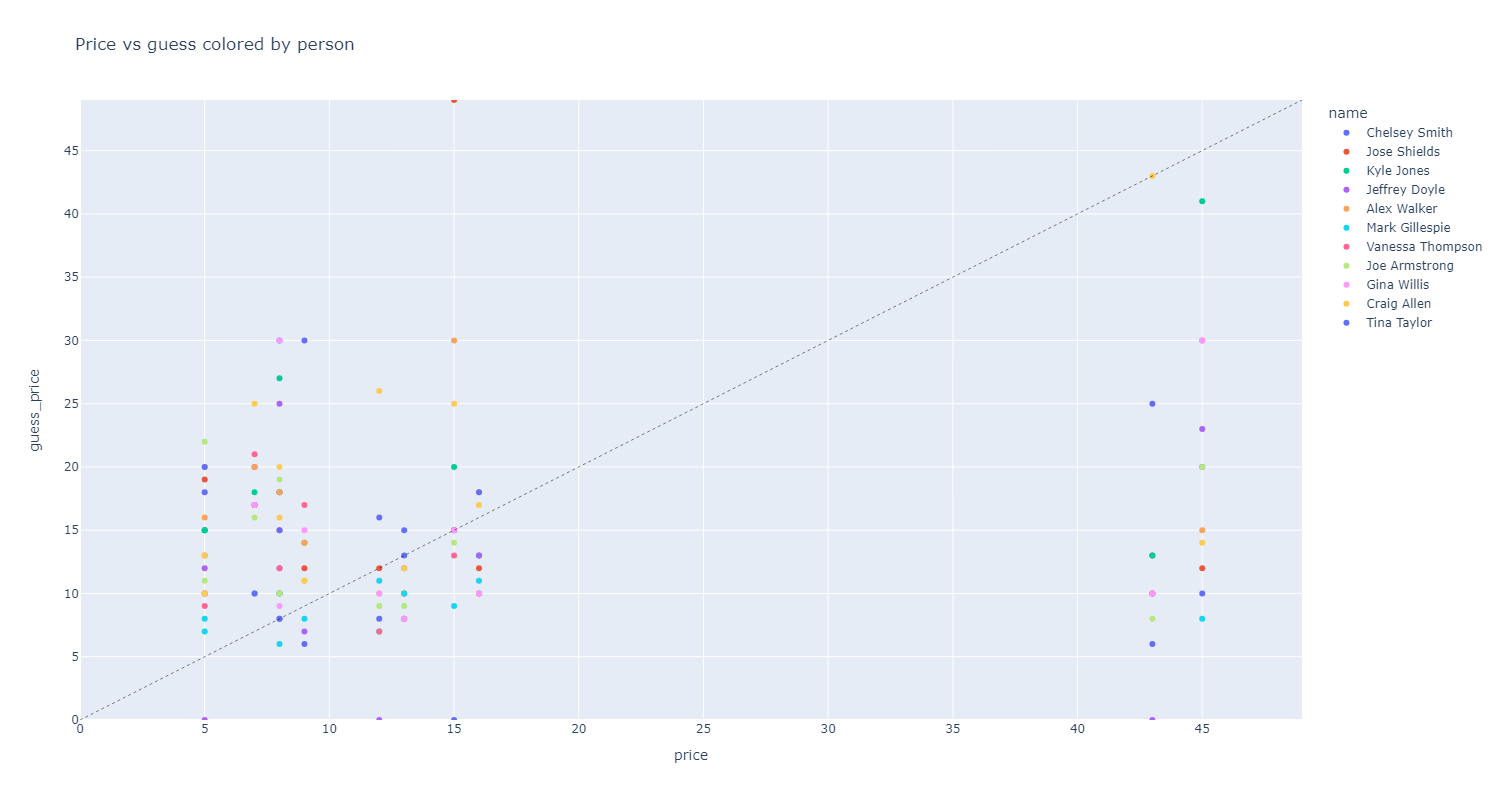

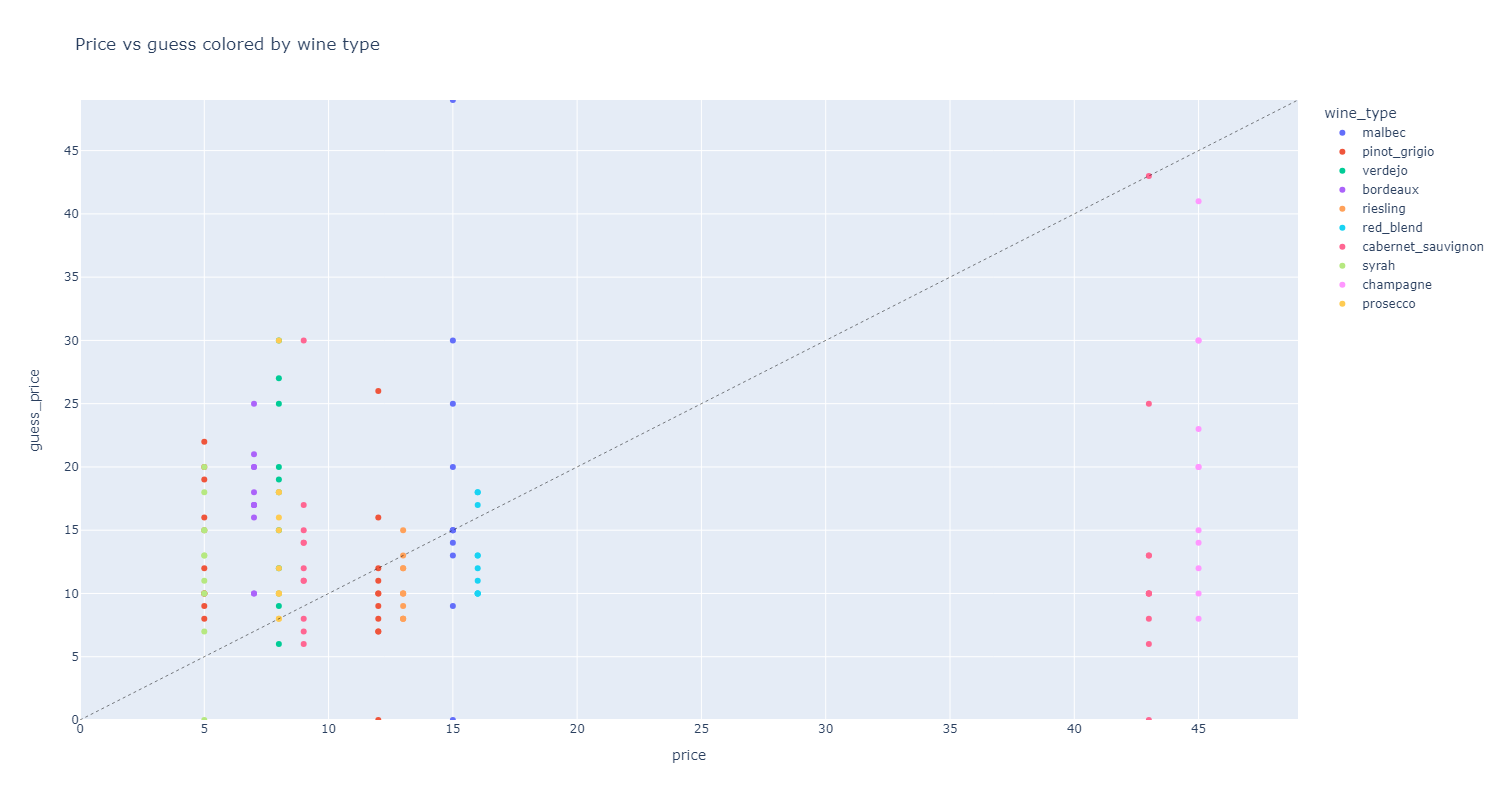

In [169]:
def make_plot(plot_df, x, y, color, title=''):
    fig=px.scatter(plot_df, x=x, y=y, color=color, width=1000, height=800, title=title, hover_data=['wine_id', 'wine_type', 'brand', 'country'])
    total_range=[0, plot_df[[x, y]].max().max()]
    fig.update_xaxes(range=total_range)
    fig.update_yaxes(range=total_range)
    fig.add_trace(go.Scatter(x=total_range, y=total_range, mode='lines', line=dict(color='black', dash='dot', width=0.5), showlegend=False))
    fig.show()

make_plot(analysis_df, 'price', 'guess_price', 'name', 'Price vs guess colored by person')
make_plot(analysis_df, 'price', 'guess_price', 'wine_type', 'Price vs guess colored by wine type')

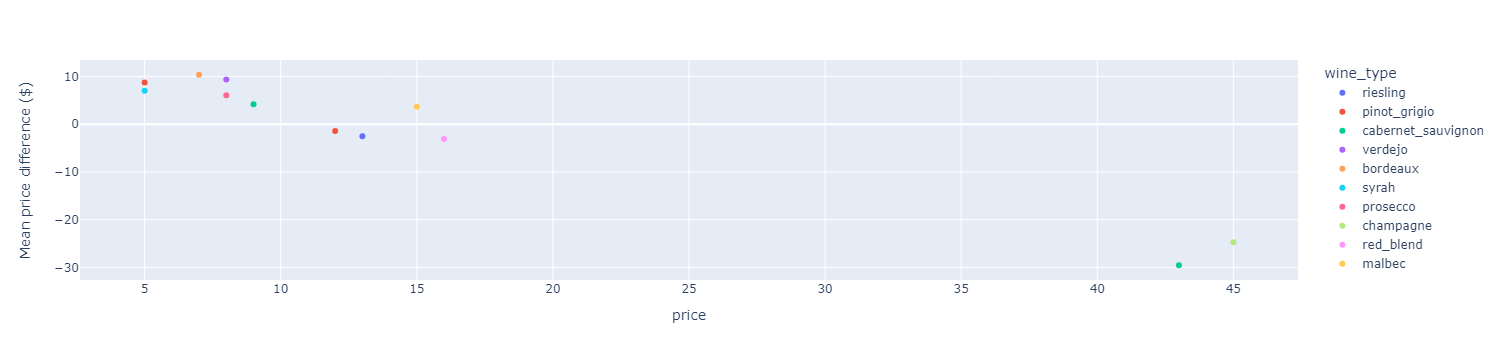

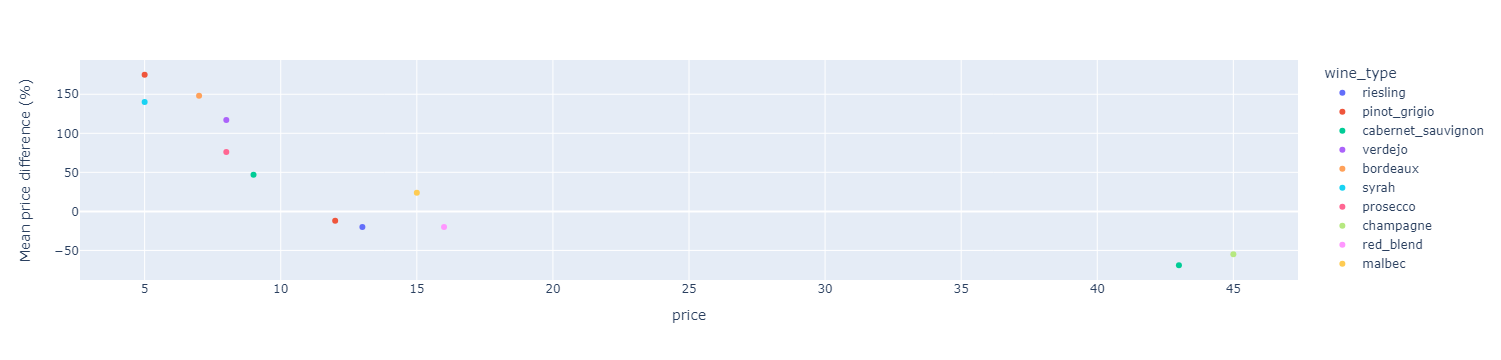

In [170]:
plot_df = analysis_df.groupby(['brand', 'wine_type', 'price'])[['price_diff', 'percent_price_diff']].mean().rename(columns={'price_diff': 'mean_price_diff', 'percent_price_diff': 'mean_percent_price_diff'})
plot_df['mean_price_diff'] = plot_df['mean_price_diff'].round(2)
plot_df['mean_percent_price_diff'] = plot_df['mean_percent_price_diff'].round(0)
plot_df = plot_df.reset_index().merge(answer_df)
plot_df['wine_type__brand'] = plot_df['wine_type'] + '__' + plot_df['brand']

px.scatter(plot_df, color='wine_type', x='price', y='mean_price_diff', hover_data=['brand'], labels={'mean_price_diff': 'Mean price difference ($)'}).show()
px.scatter(plot_df, color='wine_type', x='price', y='mean_percent_price_diff', hover_data=['brand'], labels={'mean_percent_price_diff': 'Mean price difference (%)'}).show()

In [184]:
labels

['sparkling_wine',
 'merlot',
 'na_guess_type',
 'zinfandel',
 'moscato',
 'grenache',
 'pinot_noir',
 'sauvignon_blanc',
 'verdejo',
 'bordeaux',
 'malbec',
 'pinot_grigio',
 'riesling',
 'syrah',
 'cabernet_sauvignon',
 'red_blend',
 'champagne',
 'prosecco']

In [186]:
from scipy.stats import fisher_exact
df = analysis_df.copy()
df['red'] = df['wine_type'].isin(['red_blend', 'syrah', 'cabernet_sauvignon', 'grnache', 'pinot_noir', 'bordeaux', 'malbec'])
table = np.array([
    [df.query('red==True')['correct_type'].sum(), (~df.query('red==True')['correct_type']).sum()],
    [df.query('red==False')['correct_type'].sum(), (~df.query('red==False')['correct_type']).sum()]
])
                  
res = fisher_exact(table, alternative='two-sided')
res.pvalue

0.06856205143881657

# Winners

In [171]:
performance_df = analysis_df.groupby('name')['correct_type'].sum().reset_index()
performance_df = performance_df.merge(analysis_df.groupby('name')['abs_price_diff'].mean().rename('price_error').round(2).reset_index())

In [172]:
performance_df.sort_values('correct_type', ascending=False)

,name,correct_type,price_error
1,Chelsey Smith,6,10.42
0,Alex Walker,5,11.75
2,Craig Allen,5,9.17
5,Joe Armstrong,5,10.08
8,Mark Gillespie,5,8.17
9,Tina Taylor,5,11.25
6,Jose Shields,4,12.33
10,Vanessa Thompson,4,9.25
3,Gina Willis,3,9.17
7,Kyle Jones,3,9.75


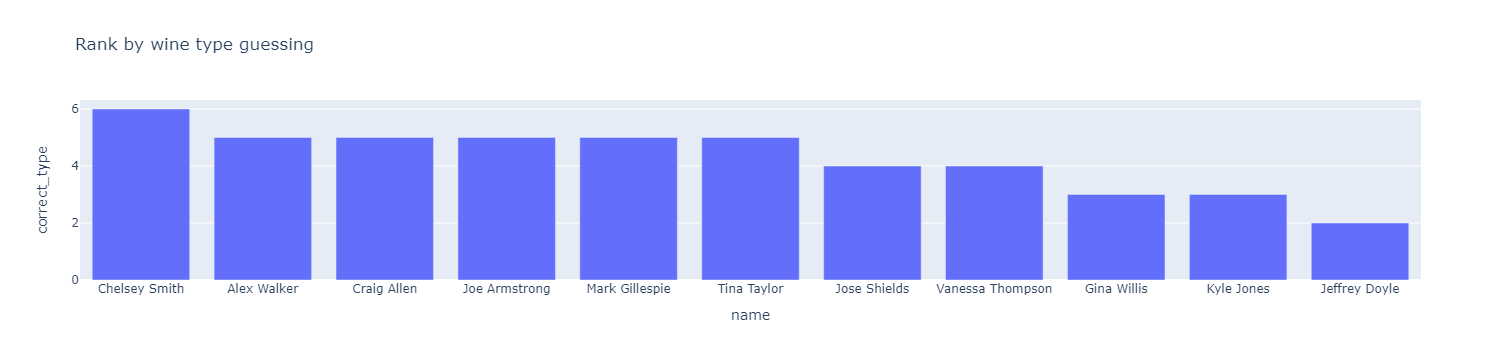

In [173]:
px.bar(performance_df.sort_values('correct_type', ascending=False), x='name', y='correct_type', title='Rank by wine type guessing')

In [174]:
performance_df.sort_values('price_error')

,name,correct_type,price_error
8,Mark Gillespie,5,8.17
2,Craig Allen,5,9.17
3,Gina Willis,3,9.17
10,Vanessa Thompson,4,9.25
7,Kyle Jones,3,9.75
5,Joe Armstrong,5,10.08
1,Chelsey Smith,6,10.42
4,Jeffrey Doyle,2,10.5
9,Tina Taylor,5,11.25
0,Alex Walker,5,11.75


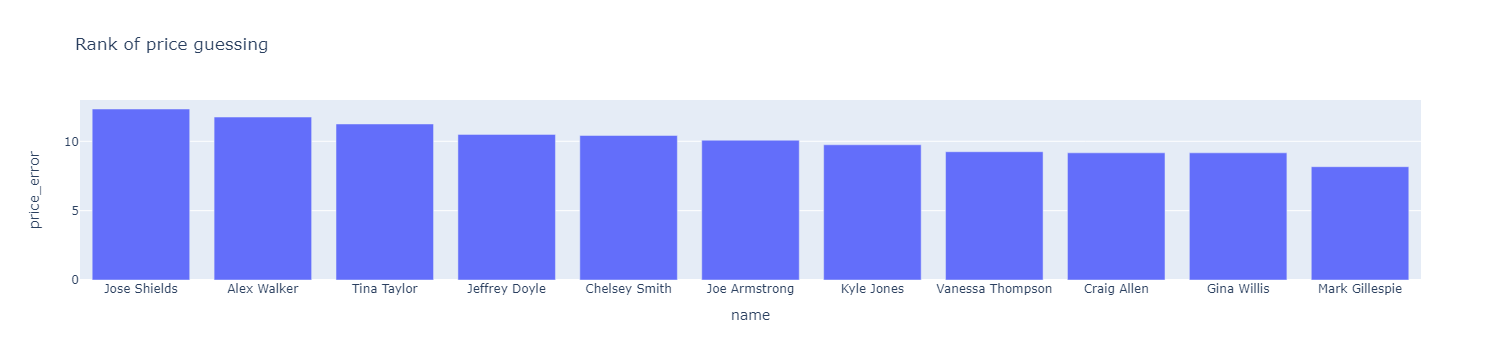

In [175]:
px.bar(performance_df.sort_values('price_error', ascending=False), x='name', y='price_error', title='Rank of price guessing')

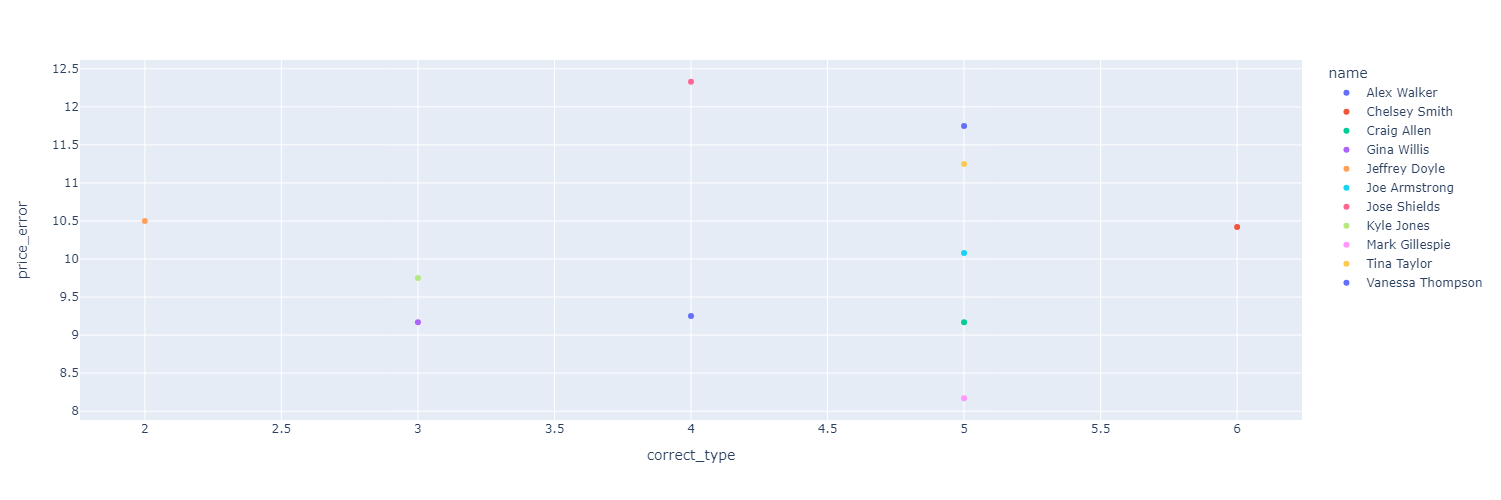

In [176]:
px.scatter(performance_df, x='correct_type', y='price_error', height=500, width=700, color='name')